In [25]:
pip install pandas numpy scikit-learn pyreadstat

In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data with Smart Filtering
def load_and_filter(file_path, target_col, missing_thresh=80, var_thresh=95):
    # Load data with metadata
    df, meta = pyreadstat.read_dta(file_path)
    
    # Save the target column separately
    target_data = df[target_col]
    
    # Phase 1: Aggressive Column Filtering
    # Remove columns with > missing_thresh% missing values (except target_col)
    missing = df.drop(columns=[target_col]).isnull().mean() * 100
    cols_to_keep = missing[missing < missing_thresh].index.tolist()
    # Add back the target column
    cols_to_keep.append(target_col)
    df = df[cols_to_keep]
    
    # Remove zero/low variance columns (except target_col)
    nunique = df.drop(columns=[target_col]).nunique()
    cols_to_keep = nunique[(nunique > 1) & (nunique < var_thresh)].index.tolist()
    # Add back the target column
    if target_col not in cols_to_keep:
        cols_to_keep.append(target_col)
    df = df[cols_to_keep]
    
    # Remove duplicate columns
    df = df.T.drop_duplicates().T
    
    return df, meta

In [36]:
# 2. Automated Feature Reduction Pipeline
def auto_feature_reducer(df, target_col='cocoa_produce', keep_percent=15):
    # Preprocessing: Encode all columns as numeric
    le = LabelEncoder()
    df = df.apply(lambda x: le.fit_transform(x.astype(str))) 
    
    # Phase 2: Correlation Filtering
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
    df = df.drop(columns=to_drop)
    
    # Phase 3: ML-Based Feature Selection
    X = df.drop(columns=[target_col])
    y = df[target_col]
    
    # First Pass: Random Forest Importance with parallel processing
    rf = RandomForestClassifier(n_estimators=100, random_state=1, n_jobs=-1)
    rf.fit(X, y)
    sfm = SelectFromModel(rf, threshold='median')
    X_reduced = sfm.transform(X)
    
    # Get the column names after the first pass
    reduced_columns = X.columns[sfm.get_support()]
    
    # Second Pass: Recursive Feature Elimination (RFE)
    # Increase the step size to eliminate more features per iteration (e.g., step=5)
    n_features_to_select = int(len(reduced_columns) * keep_percent / 100)
    rfe = RFE(
        estimator=RandomForestClassifier(random_state=1, n_jobs=-1), 
        n_features_to_select=n_features_to_select, 
        step=1  # Adjust step size to speed up the process
    )
    X_final = rfe.fit_transform(X_reduced, y)
    
    # Get final column names from the reduced set
    final_columns = reduced_columns[rfe.get_support()]
    
    return df[final_columns.tolist() + [target_col]]

In [37]:
# 3. Execution
if __name__ == "__main__":
    # Load and filter
    df, meta = load_and_filter("../data/raw/cdi_household_clean_nopii.dta", target_col='cocoa_produce')
    print(f"Post-filtering features: {len(df.columns)}")
    
    # Auto-reduce features
    final_df = auto_feature_reducer(df, keep_percent=15)
    print(f"Final feature count: {len(final_df.columns)}")
    
    # Save results
    final_df.to_csv("reduced_dataset.csv")
    
    # Generate report
    report = f"""
    Feature Reduction Report
    ========================
    Initial features: {len(meta.column_names)}
    After missing/lowvar filter: {len(df.columns)}
    Final selected features: {len(final_df.columns)}
    
    Top 10 Critical Features:
    {list(final_df.columns[:10])}
    """
    print(report)

Post-filtering features: 2537
Final feature count: 88


PermissionError: [Errno 13] Permission denied: 'reduced_dataset.csv'

In [ ]:
# Check if removed during filtering
original_df, _ = pyreadstat.read_dta("../data/raw/cdi_household_clean_nopii.dta")
print("\nOriginal columns containing 'cocoa':")
print([col for col in original_df.columns if 'cocoa' in col.lower()])


Original columns containing 'cocoa':
['screen_cocoa', 'cocoa_u', 'cocoa_unit', 'cocoa_wgt', 'cocoa_produce', 'cocoa_produce_main', 'cocoa_produce_light', 'cocoa_produce_tot', 'cocoa_sell', 'cocoa_sell_light', 'cocoa_price', 'cocoa_price_light', 'cocoa_buyer', 'cocoa_buyer_1', 'cocoa_buyer_97', 'cocoa_buyer_0', 'cocoa_buyer_888', 'cocoa_buyer_999', 'cocoa_buyero', 'cocoa_landinc', 'cocoa_howinc', 'cocoa_howinc_1', 'cocoa_howinc_2', 'cocoa_howinc_3', 'cocoa_howinc_4', 'cocoa_howinc_5', 'cocoa_howinc_6', 'cocoa_howinc_7', 'cocoa_howinc_8', 'cocoa_howinc_97', 'cocoa_howinc_oth', 'cocoa_howdec', 'cocoa_howdec_1', 'cocoa_howdec_2', 'cocoa_howdec_3', 'cocoa_howdec_4', 'cocoa_howdec_6', 'cocoa_howdec_5', 'cocoa_howdec_97', 'cocoa_howdec_oth', 'cocoa_1', 'cocoa_yn_1', 'cocoa_years_1', 'cocoa_lndamnt_1', 'cocoa_variety_1', 'cocoa_variety_1_1', 'cocoa_variety_2_1', 'cocoa_variety_3_1', 'cocoa_variety_4_1', 'cocoa_variety_5_1', 'cocoa_variety_97_1', 'cocoa_variety_oth_1', 'cocoa_species_num_1', '

Feature Importances:
               Feature  Importance
1          hhmem_age_1    0.026403
5          hhmem_age_3    0.025533
58              pest_1    0.021907
3          hhmem_age_2    0.021753
31       cocoa_years_1    0.020499
..                 ...         ...
64      farm_reserve_2    0.006395
44  shadetree_calc_1_2    0.006356
4          hh_relate_3    0.005826
38     shadetree_num_1    0.005537
15          adultf_num    0.005364

[86 rows x 2 columns]


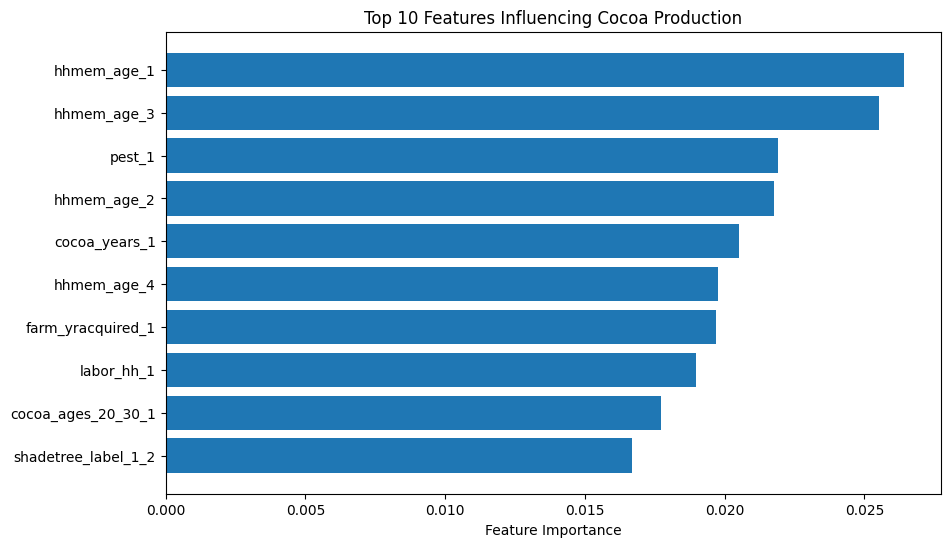

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Load the reduced dataset
df = pd.read_csv("reduced_dataset.csv")

# Drop columns that are not relevant
columns_to_drop = ["Unnamed: 0", "today"]
for col in columns_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])

# Assume the target variable is 'cocoa_produce'
target = 'cocoa_produce'
X = df.drop(columns=[target])
y = df[target]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Fit a Random Forest Regressor with parallel processing
rfr = RandomForestRegressor(n_estimators=100, random_state=1, n_jobs=-1)
rfr.fit(X_train, y_train)

# Get feature importances from the model
importances = rfr.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

# Optionally, plot the top 10 features
top_n = 10
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:top_n], importance_df['Importance'][:top_n])
plt.xlabel("Feature Importance")
plt.title("Top 10 Features Influencing Cocoa Production")
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()


In [35]:
import pandas as pd
import statsmodels.api as sm

# 1. Load the reduced dataset (make sure it contains 'cocoa_produce')
df_ols = pd.read_csv("reduced_dataset.csv")

# Optional: Drop columns like 'Unnamed: 0' if they exist
if "Unnamed: 0" in df_ols.columns:
    df_ols.drop(columns=["Unnamed: 0"], inplace=True)

# 2. Define the target and features
target = "cocoa_produce"
X = df_ols.drop(columns=[target])
y = df_ols[target]

# 3. Add a constant for the OLS intercept
X = sm.add_constant(X)

# 4. Fit the OLS model
model = sm.OLS(y, X).fit()

# 5. Print the summary of the model
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          cocoa_produce   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     1.355
Date:                Sat, 01 Mar 2025   Prob (F-statistic):             0.0188
Time:                        20:58:50   Log-Likelihood:                -8909.7
No. Observations:                1505   AIC:                         1.800e+04
Df Residuals:                    1417   BIC:                         1.846e+04
Df Model:                          87                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  103.9720 